<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google/meridian/blob/main/demo/Meridian_Prior_Calibration_JAX.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google/meridian/blob/main/demo/Meridian_Prior_Calibration_JAX.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

# **Meridian Prior Calibration Demo**

Welcome to the Meridian demo for **Prior Calibration** (also known as the prior
translator).

Prior Calibration allows you to incorporate incrementality experiment results
directly into your Marketing Mix Model (MMM) as Bayesian priors. Rather than
using the raw point estimates and standard errors directly, Meridian's prior
translator (`CalibrationBuilder`) automatically applies statistical adjustments
to align the experiments with the MMM's scope, timing, and duration.

### **How Translation & Adjustments Work**

To bridge the gap between experimental conditions and the MMM, Meridian applies
three key adjustments:

1.  **Spend Adjustment**: Accounts for the difference in spend scale. If an
    experiment covers only a small fraction of the total spend in the MMM
    modeling window, the prior's uncertainty (variance) is increased.
2.  **Recency Adjustment**: Discounts older experiments using an exponential
    decay with a 52-week (1-year) half-life, adding more uncertainty to
    historical results.
3.  **Duration Adjustment**: Adjusts the point estimate and variance to account
    for carryover effects (adstock decay) by calculating the proportion of the
    media effect captured during the experiment's active weeks.

### **Overview of Calibration Scenarios**

In this notebook, we will demonstrate how to calibrate priors for three distinct
channel scenarios:

-   **Case A (GeoX Channel)**: Calibrating a channel using experiment results
    derived from Google's GeoX tool.
-   **Case B (Non-GeoX Channel)**: Calibrating a channel using generic
    incrementality experiments from non-GeoX sources.
-   **Case C (GeoX + Non-GeoX Channel)**: Calibrating a channel using a
    combination of both GeoX and generic experiments.

--------------------------------------------------------------------------------

### **Notebook Outline**

<ol>
  <li><a href="#setup">Step 0: Setup and Environment Imports</a></li>
  <li><a href="#load-data">Step 1: Load Sample Data</a></li>
  <li><a href="#prior-calibration">Step 2: Run Prior Calibration</a></li>
  <li><a href="#build-priors">Step 3: Build and Inspect Calibrated Priors</a></li>
  <li><a href="#run-model">Step 4: Configure and Initialize the Meridian Model</a></li>
</ol>

<a name="setup"></a>

## Step 0: Setup and Environment Imports

First, we will set up the python environment.

In [ ]:

!pip install --upgrade "google-meridian[colab,and-cuda] @ git+https://github.com/google/meridian.git@test_975534109"
!pip install meridian-geox

  Cloning https://github.com/google/meridian.git (to revision test_970525035) to /tmp/pip-install-pguk0wf2/google-meridian_350741e5d921435db033267a4aed1697
  Running command git clone --filter=blob:none --quiet https://github.com/google/meridian.git /tmp/pip-install-pguk0wf2/google-meridian_350741e5d921435db033267a4aed1697
  Running command git checkout -b test_970525035 --track origin/test_970525035
  Switched to a new branch 'test_970525035'
  Branch 'test_970525035' set up to track remote branch 'test_970525035' from 'origin'.
  Resolved https://github.com/google/meridian.git to commit d3328b197dc7e225b2818a73711d3f3fc6e46870
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.6 MB/s eta 0:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 38.8 MB/s eta 0:00:00


In [ ]:
import jax
import os

from meridian import constants
from meridian.data import data_frame_input_data_builder
from meridian.model import model
from meridian.model import prior_distribution
from meridian.model import spec
from meridian.model.calibration import prior_builder
try:
  from meridian_geox import api as geox_api
except ImportError:
  print("Warning: 'meridian_geox' is not installed directly. Install it via: pip install 'google-meridian[geox]'.")

import datetime
import pandas as pd
import numpy as np
from psutil import virtual_memory

ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 54.8 gigabytes of available RAM


<a name="load-data"></a>

## Step 1: Load Sample Data

We will read the simulated multi-channel dataset into a Pandas DataFrame and
construct the Meridian `InputData` object using `DataFrameInputDataBuilder`.

In [ ]:
csv_path = "https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_all_channels.csv"

df = pd.read_csv(csv_path, index_col=0)

# Create data builder with non-revenue KPI (conversions)
# Note: prior calibration for models with non-revenue KPIs requires revenue_per_kpi information
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type='non_revenue'
)

builder = (
    builder.with_kpi(df, kpi_col='conversions')
    .with_revenue_per_kpi(df, revenue_per_kpi_col='revenue_per_conversion')
    .with_population(df)
    .with_controls(
        df, control_cols=['sentiment_score_control', 'competitor_sales_control']
    )
)

channels = ['Channel0', 'Channel1', 'Channel2', 'Channel3', 'Channel4']
builder = builder.with_media(
    df,
    media_cols=[f'{channel}_impression' for channel in channels],
    media_spend_cols=[f'{channel}_spend' for channel in channels],
    media_channels=channels,
)

data = builder.build()
print(f'InputData successfully built with {len(channels)} active channels.')

InputData successfully built with 5 active channels.


<a name="prior-calibration"></a>

## Step 2: Run Prior Calibration

In this step, we will initialize `CalibrationBuilder` and construct mock
experiment results so the notebook is executable end-to-end.

We first write a helper function to create a mock `geox_api.AnalysisResult`
since running GeoX results from file would require a locally saved analysis
result run file.

In [ ]:
def create_mock_geox_result(
    point_estimate,
    standard_deviation,
    estimated_bau_spend,
    start_date,
    end_date,
):
  """Creates a mock GeoX AnalysisResult object containing required target statistics."""
  icpd_estimate = geox_api.Estimate(
      point_estimate=point_estimate,
      lower_bound=point_estimate - 1.96 * standard_deviation,
      upper_bound=point_estimate + 1.96 * standard_deviation,
      standard_deviation=standard_deviation,
      p_value=0.05,
  )
  desc_metrics = geox_api.DescriptiveMetrics(
      estimated_bau_spend=estimated_bau_spend
  )
  cell_metrics = geox_api.AnalysisMetrics(
      lift=icpd_estimate,
      percent_lift=icpd_estimate,
      icpd=icpd_estimate,
      descriptive_metrics=desc_metrics,
  )

  # Creating minimal Design parameters
  per_cell_design = geox_api.PerCellDesign(
      treatment_geos={'geo_1'},
      minimum_detectable_effect=0.1,
      design_implied_cpic=1.0,
      p_value=0.05,
      budget=estimated_bau_spend,
  )
  mock_design = geox_api.Design(
      designs={'cell_1': per_cell_design},
      control_geos={'geo_2'},
      excluded_geos=set(),
  )

  analysis_config = geox_api.AnalysisConfig(
      design=mock_design,
      analysis_start_date=pd.Timestamp(start_date),
      analysis_end_date=pd.Timestamp(end_date),
  )
  return geox_api.AnalysisResult(
      results={'cell_1': cell_metrics},
      analysis_config=analysis_config,
  )


# Set experiment dates within the modeling window
first_date = data.time_coordinates.all_dates[0]
exp_start = first_date
exp_end = exp_start + datetime.timedelta(weeks=4)
print(f'Experiment start: {exp_start}, end: {exp_end}')

Experiment start: 2021-01-25, end: 2021-02-22


### **Initialize CalibrationBuilder**

To calibrate priors, we instantiate `CalibrationBuilder` by passing the
`InputData` object.

In [ ]:
cal_builder = prior_builder.CalibrationBuilder(data=data)

### **Case A: Direct import of Meridian GeoX Experiment Result**

Register the GeoX result for `Channel0` using
`with_meridian_geox_experiment_result`.

In [ ]:
channel0_total_spend = cal_builder._get_channel_total_spend('Channel0')

# Construct a GeoX result for Channel0
geox_res = create_mock_geox_result(
    point_estimate=2.5,
    standard_deviation=0.5,
    estimated_bau_spend=channel0_total_spend * 0.1,
    start_date=datetime.datetime.combine(exp_start, datetime.time()),
    end_date=datetime.datetime.combine(exp_end, datetime.time()),
)

cal_builder.with_meridian_geox_experiment_result(
    channel_name='Channel0',
    geox_results=geox_res,
    experiment_kpi_types=constants.NON_REVENUE,
)

### **Case B: Manually enter GeoX or Generic Experiment Result**

For channels with generic incrementality experiments, we register them using
`with_incrementality_experiment_result`.

We will register a generic experiment for `Channel1`.

In [ ]:
channel1_total_spend = cal_builder._get_channel_total_spend('Channel1')

cal_builder.with_incrementality_experiment_result(
    channel_name='Channel1',
    point_estimates=1.8,
    standard_errors=0.4,
    experiment_kpi_types=constants.NON_REVENUE,
    experiment_total_spends=channel1_total_spend * 0.15,
    experiment_start_dates=exp_start,
    experiment_end_dates=exp_end,
)

### **Case C: Channel with both GeoX and Non-GeoX Experiment Results**

We can easily register multiple experimental sources for the same channel.
`CalibrationBuilder` handles Mixed Calibration by adjusting both and executing a
joint Bayesian numeric grid update to combine them.

We will register a GeoX experiment AND a generic experiment for `Channel2`.

In [ ]:
channel2_total_spend = cal_builder._get_channel_total_spend('Channel2')

# 1. Register a GeoX experiment
geox_res2 = create_mock_geox_result(
    point_estimate=3.0,
    standard_deviation=0.6,
    estimated_bau_spend=channel2_total_spend * 0.05,
    start_date=datetime.datetime.combine(exp_start, datetime.time()),
    end_date=datetime.datetime.combine(exp_end, datetime.time()),
)
cal_builder.with_meridian_geox_experiment_result(
    channel_name='Channel2',
    geox_results=geox_res2,
    experiment_kpi_types=constants.NON_REVENUE,
)

# 2. Register a generic experiment
cal_builder.with_incrementality_experiment_result(
    channel_name='Channel2',
    point_estimates=2.2,
    standard_errors=0.5,
    experiment_kpi_types=constants.NON_REVENUE,
    experiment_total_spends=channel2_total_spend * 0.08,
    experiment_start_dates=exp_start,
    experiment_end_dates=exp_end,
)

<a name="build-priors"></a>

## Step 3: Build and Inspect Calibrated Priors

We now invoke the `build()` method to compile the adjusted experiment results
and generate the calibrated ROI prior distributions.

In [ ]:
import time

# Build the prior distributions
start_time = time.time()
priors = cal_builder.build()
end_time = time.time()

# The output will contain 'roi_m' representing the joint multivariate prior for media channels
roi_m_dist = priors.roi_m
print('Calibrated Joint Prior Distribution:')
print(roi_m_dist)
print(
    f'Time taken to build prior distributions: {end_time - start_time:.4f}'
    ' seconds'
)

/usr/local/lib/python3.13/dist-packages/meridian/backend/__init__.py:711: UserWarning: Input data is float64. Casting to float32 to match backend default precision.
  warnings.warn(


Calibrated Joint Prior Distribution:
tfp.distributions.CalibratedDistribution("roi_m", batch_shape=[5], event_shape=[], dtype=float32)
Time taken to build prior distributions: 8.4609 seconds


<a name="run-model"></a>

## Step 4: Configure and Initialize the Meridian Model

Finally, we pack the calibrated joint distributions into the `PriorDistribution`
class, specify the `'roi'` prior type in `ModelSpec`, and build our `Meridian`
model.

In [ ]:
# Initialize PriorDistribution wrapping the calibrated joint prior
prior_dist = prior_distribution.PriorDistribution(roi_m=priors.roi_m)

# Define ModelSpec targeting 'roi' prior type
model_spec = spec.ModelSpec(prior=prior_dist, media_prior_type='roi')

# Build Meridian Model
mmm = model.Meridian(input_data=data, model_spec=model_spec)
print('Meridian model initialized successfully with prior calibration!')

Meridian model initialized successfully with prior calibration!


<a name="appendix"></a>

## Appendix: Visualize ROI Prior Distributions

To check how the different calibration setups affect our model priors, we can
sample the joint ROI prior distribution `roi_m` and plot the resulting
probability densities for each media channel.

Visualizing prior distributions:


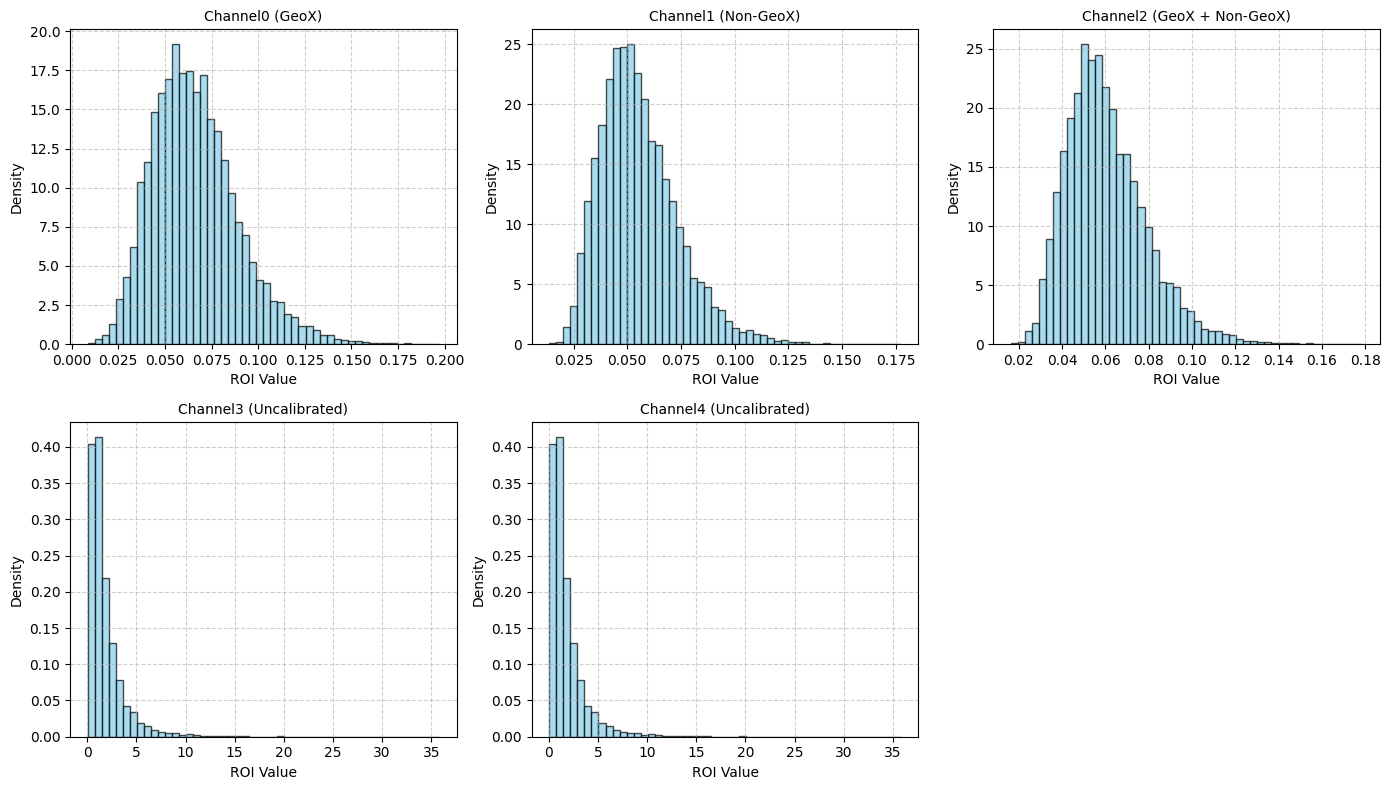

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print('Visualizing prior distributions:')

# Sample from the joint prior distribution.
samples = roi_m_dist.sample(10000, seed=jax.random.PRNGKey(42))


samples_np = np.asarray(samples)
channels = [
    'Channel0 (GeoX)',
    'Channel1 (Non-GeoX)',
    'Channel2 (GeoX + Non-GeoX)',
    'Channel3 (Uncalibrated)',
    'Channel4 (Uncalibrated)',
]

# Clear any previous figures and draw subplots for each channel prior
plt.figure(figsize=(14, 8))
for i, channel_name in enumerate(channels):
  plt.subplot(2, 3, i + 1)
  plt.hist(
      samples_np[:, i],
      bins=50,
      density=True,
      alpha=0.7,
      color='skyblue',
      edgecolor='black',
  )
  plt.title(channel_name, fontsize=10)
  plt.xlabel('ROI Value')
  plt.ylabel('Density')
  plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()